In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

from dynsel import ratio_robustness
from plotting import accuracy_rejection_curve

!pip install -U --no-cache-dir gdown --pre

In [2]:
# Load cached data
if not os.path.exists("../data"):
    os.system("gdown 1h7S6N_Rx7gdfO3ZunzErZy6H7620EbZK -O ../data.tar.gz")
    os.system("tar -xf ../data.tar.gz -C ../")
    os.system("rm ../data.tar.gz")
if not os.path.exists("../data/imagenet/human_readable_labels.json"):
    !wget -nv -O ../data/imagenet/human_readable_labels.json -L https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json

data = np.load("../data/imagenet/imagenet-resnet152.npz")
example_paths = os.listdir("../data/imagenet/examples")
smx = data["smx"]
labels = data["labels"].astype(int)

In [3]:
# Robustness values
rob=ratio_robustness(np.log(smx))

# Predictions
right_class=(np.argmax(smx, axis=1)==labels)*1

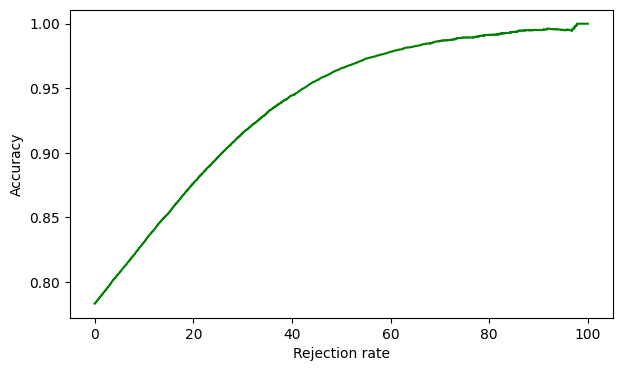

In [4]:
# Accuracy rejection curve
accuracy_rejection_curve(rob, right_class)